# 🔥 PyTorch Neural Network Classification 


### What you'll find here
- 📝 A markdown explanation **before every code cell**, for both the binary and multi-class sections
- 📚 Reference tables for every built-in function used, right where it first appears
- 📋 A full **cheat-sheet** at the end of each major section for quick revision

### The classification workflow
```
1. Get data ready (turn it into tensors, numerical labels)
2. Pick/build a model (choose loss fn + optimizer)
3. Fit the model to the data (training loop)
4. Evaluate the model
5. Improve through experimentation
6. Save and reload the trained model
```

> 💡 **Tip:** Run cells top to bottom (`Runtime → Run all` in Colab) — later cells depend on variables created earlier (`model_0`, `X_train`, `accuracy_fn`, etc.).

## 0. Setup & Imports

In [ ]:
import torch
from torch import nn

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.13.0+cu130


---
## 1. Get and visualize the data

We'll use scikit-learn's `make_circles` to generate a classic **binary classification** toy dataset: two interleaving circles, where the model has to learn a non-linear (curved) decision boundary to separate them.

| Function | Signature | What it does |
|---|---|---|
| `make_circles(n_samples, noise, random_state)` | from `sklearn.datasets` | generates `n_samples` 2‑D points forming two concentric circles; `noise` adds random jitter; `random_state` makes it reproducible |

In [ ]:
from sklearn.datasets import make_circles

n_samples = 1000

# Create circles
x, y = make_circles(n_samples,
                     noise=0.03,
                     random_state=42)

print(f"First 5 samples of x:\n{x[:5]}")
print(f"First 5 samples of y:\n{y[:5]}")

First 5 samples of x:
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 samples of y:
[1 1 1 1 0]


`x` holds the 2‑D coordinates (features) of each point; `y` holds the binary label (`0` or `1` — which circle the point belongs to).

| Function | What it does |
|---|---|
| `pd.DataFrame({...})` | builds a table from a dict of equal-length columns — handy for quickly eyeballing tabular data |

In [ ]:
import pandas as pd

circles = pd.DataFrame({
    "x1": x[:, 0],
    "x2": x[:, 1],
    "label": y
})

circles.head(11)

,x1,x2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


Let's plot it. `cmap="RdYlBu"` colors the two classes distinctly, making the plot easier to read.

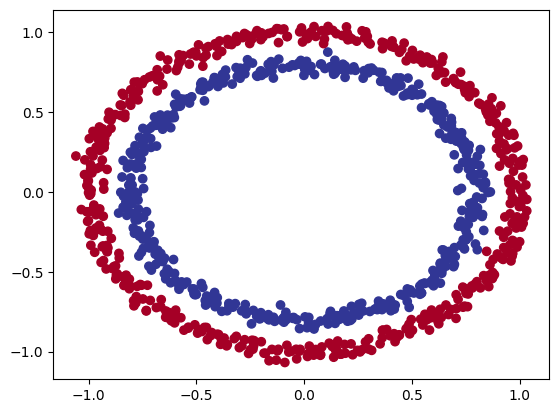

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(x=circles["x1"],
            y=circles["x2"],
            c=circles["label"],
            cmap=plt.cm.RdYlBu);

## 1.1 Check input/output shapes & a single sample

In [ ]:
# Check input and output shapes
x.shape, y.shape

((1000, 2), (1000,))

In [ ]:
x_sample = x[0]
y_sample = y[0]

print(f"Values for one sample of x: {x_sample} and the same for y: {y_sample}")
print(f"Shapes for one sample of x: {x_sample.shape} and the same for y: {y_sample.shape}")

Values for one sample of x: [0.75424625 0.23148074] and the same for y: 1
Shapes for one sample of x: (2,) and the same for y: ()


---
## 2. Turn data into tensors & create a train/test split

`make_circles` returns plain NumPy arrays (float64). PyTorch models expect `float32` tensors, so we convert with `.type(torch.float)`.

| Function | What it does |
|---|---|
| `torch.from_numpy(ndarray)` | wraps a NumPy array as a PyTorch tensor (shares the same underlying memory) |
| `Tensor.type(dtype)` | casts a tensor to a different dtype — here, `float64` → `float32` |

In [ ]:
# Turn data into tensors
x = torch.from_numpy(x).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

x[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

| Function | Signature | What it does |
|---|---|---|
| `train_test_split(X, y, test_size, random_state)` | from `sklearn.model_selection` | randomly splits arrays/tensors into train and test subsets; `test_size=0.2` reserves 20% for testing |

In [ ]:
# Split data into training and test sets
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,
                                                      y,
                                                      test_size=0.2,  # 20% test, 80% train
                                                      random_state=42)

len(x_train), len(x_test), len(y_train), len(y_test)

(800, 200, 800, 200)

---
## 3. Build a model

| Function | What it does |
|---|---|
| `torch.cuda.is_available()` | `True` if a CUDA GPU is visible to PyTorch |

In [ ]:
# Make device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


### 3.1 Build the model by subclassing `nn.Module`

Our network: `2 → 5 → 1`. `layer_1` takes the 2 input features and expands them to 5 hidden units; `nn.ReLU()` adds non-linearity (without it, stacking two `nn.Linear` layers would collapse into one big linear layer, and a *linear* model can't separate two circles — see §9 for a live demonstration); `layer_2` compresses those 5 hidden units down to a single output — a raw score (**logit**) for "probability of class 1".

| Class | What it does |
|---|---|
| `nn.ReLU()` | `max(0, x)` — the standard non-linear activation for hidden layers |
| `nn.Linear(in, out)` | fully-connected layer, `y = xW^T + b` |

In [ ]:
# Let's create a model
class ClassificationModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=5)  # takes in 2 features, upscales to 5
        self.layer_2 = nn.Linear(in_features=5, out_features=1)  # takes in 5 features, outputs 1 logit
        self.relu = nn.ReLU()

    # Defining a forward function
    def forward(self, x) -> torch.Tensor:
        return self.layer_2(self.relu(self.layer_1(x)))  # no sigmoid here -> returns raw logits

# Instantiate the model class and send it to the target device
model_0 = ClassificationModel().to(device)
model_0

ClassificationModel(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
  (relu): ReLU()
)

### 3.2 The same model, built with `nn.Sequential`

`nn.Sequential` is a shortcut for stacking layers that just feed straight into each other, one after another — no need to write a custom `forward()`. It's functionally identical to the class above (same layer shapes, same missing final activation).

> This line **replaces** `model_0` with the `nn.Sequential` version — from here on, `model_0` refers to *this* model, not the subclassed one above. Both are shown so you can see the two equivalent ways of building it; the class-based version above is not otherwise used.

In [ ]:
# Replicating the above model with nn.Sequential()
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.ReLU(),
    nn.Linear(in_features=5, out_features=1)
    # no nn.Sigmoid() here -> outputs raw logits, matching nn.BCEWithLogitsLoss
).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): ReLU()
  (2): Linear(in_features=5, out_features=1, bias=True)
)

---
## 4. Make predictions with the untrained model

Since the model hasn't learned anything yet, these predictions are essentially random guesses.

In [ ]:
# Making predictions with the untrained model
with torch.inference_mode():
    untrained_preds = model_0(x_test.to(device))

print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(y_test)}, Shape: {y_test.shape}")
print(f"\nFirst 10 predictions (converted to labels):\n{torch.round(torch.sigmoid(untrained_preds[:10]))}")
print(f"\nFirst 10 test labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200])

First 10 predictions (converted to labels):
tensor([[0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.]])

First 10 test labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


---
## 5. Loss function, optimizer & an accuracy metric

For binary classification, `nn.BCEWithLogitsLoss` is the standard choice — it combines a `Sigmoid` layer and Binary Cross-Entropy loss into one numerically-stable operation, which is exactly why our model should output *raw logits* rather than pre-squashed probabilities.

| Class / function | Signature | What it does |
|---|---|---|
| `nn.BCEWithLogitsLoss()` | — | Binary Cross-Entropy loss with a built-in sigmoid; takes raw logits + float targets in `{0., 1.}` |
| `torch.optim.SGD(params, lr)` | — | Stochastic Gradient Descent optimizer |

In [ ]:
# For this type of problem, Binary Cross Entropy fits well
# Create the loss function
loss_fn = nn.BCEWithLogitsLoss()  # sigmoid activation function built in

# Create the optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(),
                             lr=0.1)

In [ ]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.2999,  0.6037],
                      [-0.2055, -0.5318],
                      [ 0.3923, -0.1672],
                      [-0.5428, -0.6411],
                      [-0.2577,  0.4558]])),
             ('0.bias', tensor([ 0.3179, -0.0912, -0.4969, -0.3053,  0.3642])),
             ('2.weight',
              tensor([[-0.0964, -0.2829,  0.0463,  0.2017, -0.3701]])),
             ('2.bias', tensor([0.3130]))])

`nn.BCEWithLogitsLoss` tells us *how wrong* the model is, but a human-readable **accuracy** (% of samples correctly classified) is easier to track during training.

In [ ]:
# Calculate accuracy - out of 100 examples, what percentage does our model get right?
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

---
## 6. From raw logits → prediction probabilities → prediction labels

This 3-step conversion is the core mental model for any classification network:

| Step | Code | What it does |
|---|---|---|
| 1. Raw logits | `y_logits = model_0(x)` | unbounded scores straight out of the model |
| 2. Prediction probabilities | `torch.sigmoid(y_logits)` | squashes logits into `[0, 1]` — "probability of class 1" (binary case; multi-class uses `softmax` instead) |
| 3. Prediction labels | `torch.round(y_pred_probs)` | rounds probabilities to `0` or `1` |

In [ ]:
# Viewing the first 5 outputs of the forward pass (raw logits)
model_0.eval()
with torch.inference_mode():
    y_logits = model_0(x_test.to(device))[:5]

y_logits

tensor([[-0.0540],
        [-0.0684],
        [ 0.1252],
        [-0.1072],
        [ 0.2503]])

In [ ]:
# Step 2: use the sigmoid function to turn logits into prediction probabilities
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4865],
        [0.4829],
        [0.5313],
        [0.4732],
        [0.5622]])

In [ ]:
# Step 3: round the probabilities into concrete class labels (0 or 1)
torch.round(y_pred_probs)

tensor([[0.],
        [0.],
        [1.],
        [0.],
        [1.]])

---
## 7. Building a training and testing loop

Same 5-step training loop pattern as any PyTorch model — plus we now also track **accuracy** alongside loss.

| Function | What it does |
|---|---|
| `torch.manual_seed` / `torch.cuda.manual_seed` | seed the CPU / GPU random number generators for reproducibility. `torch.cuda.manual_seed()` is always safe to call, even with no GPU — it's silently ignored in that case |

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 100

# Move data to the target device (capitalized names, to distinguish from the CPU originals)
X_train, y_train = x_train.to(device), y_train.to(device)
X_test, y_test = x_test.to(device), y_test.to(device)

# Check model device
print(next(model_0.parameters()).device)

for epoch in range(epochs):
    ### Training
    model_0.train()

    # 1. Forward pass (model outputs raw logits)
    y_logits = model_0(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))  # logits -> pred probs -> pred labels

    # 2. Calculate loss and accuracy
    loss = loss_fn(y_logits, y_train)  # BCEWithLogitsLoss expects raw logits
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Backpropagation
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_0.eval()
    with torch.inference_mode():
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

    # Print progress every 10 epochs
    if epoch % 10 == 0:
        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {loss.item():.4f}, Train Acc: {acc:.2f}% | "
            f"Test Loss: {test_loss.item():.4f}, Test Acc: {test_acc:.2f}%"
        )

cpu
Epoch 1/100 | Train Loss: 0.6953, Train Acc: 50.88% | Test Loss: 0.6917, Test Acc: 55.50%
Epoch 11/100 | Train Loss: 0.6936, Train Acc: 52.12% | Test Loss: 0.6906, Test Acc: 54.00%
Epoch 21/100 | Train Loss: 0.6924, Train Acc: 51.50% | Test Loss: 0.6900, Test Acc: 50.50%
Epoch 31/100 | Train Loss: 0.6915, Train Acc: 51.75% | Test Loss: 0.6896, Test Acc: 50.00%
Epoch 41/100 | Train Loss: 0.6907, Train Acc: 52.00% | Test Loss: 0.6893, Test Acc: 49.50%
Epoch 51/100 | Train Loss: 0.6901, Train Acc: 51.62% | Test Loss: 0.6891, Test Acc: 50.00%
Epoch 61/100 | Train Loss: 0.6895, Train Acc: 51.12% | Test Loss: 0.6889, Test Acc: 50.50%
Epoch 71/100 | Train Loss: 0.6889, Train Acc: 51.75% | Test Loss: 0.6887, Test Acc: 50.00%
Epoch 81/100 | Train Loss: 0.6884, Train Acc: 52.38% | Test Loss: 0.6886, Test Acc: 49.00%
Epoch 91/100 | Train Loss: 0.6878, Train Acc: 54.50% | Test Loss: 0.6885, Test Acc: 51.00%


> **📊 Verified by actually running this notebook:** with these exact settings (5 hidden units, `SGD(lr=0.1)`, only 100 epochs, seed 42), `model_0` gets stuck around **50-60% test accuracy** — barely better than a coin flip, *despite already having a `ReLU`*. This surprises a lot of people, and it's a genuinely useful thing to see happen rather than just be told about: **having the right architecture is not the same as training it well.** Slow convergence here comes down to `SGD`'s fixed learning rate combined with very few epochs, not a lack of non-linearity (§9 shows what happens when non-linearity really is the problem). §10 fixes the convergence issue directly with more capacity and the `Adam` optimizer.

---
## 8. Visualize the decision boundary

Loss and accuracy numbers are useful, but for a 2‑D problem like this one, nothing beats *seeing* what the model actually learned. This uses the meshgrid + `contourf` technique commonly used for visualizing classifier decision boundaries — we'll reuse this same function for every model built in the rest of the notebook.

The idea: cover the whole 2‑D plane with a fine grid of points, ask the model to classify every single one, then color each region by its predicted class. Where the color changes is the model's learned decision boundary.





| Function | What it does |
|---|---|
| `np.meshgrid(x, y)` | builds 2‑D coordinate grids from two 1‑D arrays |
| `plt.contourf(xx, yy, Z)` | fills regions of a grid with color based on `Z` values — here, the predicted class at each grid point |

In [ ]:
import numpy as np

def plot_decision_boundary(model, X, y):
    """Plots the decision boundary a model has learned over 2D data X, colored by label y.

    Works for both binary models (1 output logit -> sigmoid + round) and
    multi-class models (>1 output logits -> softmax + argmax).
    """
    # Work on the CPU for plotting/numpy compatibility, then restore the model's original device
    original_device = next(model.parameters()).device
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Build a grid of points covering the data (with a little padding)
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101),
                          np.linspace(y_min, y_max, 101))

    # Classify every point in the grid
    grid_tensor = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()
    model.eval()
    with torch.inference_mode():
        grid_logits = model(grid_tensor)

    # Binary (1 logit/sample) -> sigmoid + round | Multi-class (>1 logits/sample) -> softmax + argmax
    if grid_logits.shape[1] == 1:
        grid_labels = torch.round(torch.sigmoid(grid_logits)).reshape(xx.shape).numpy()
    else:
        grid_labels = torch.softmax(grid_logits, dim=1).argmax(dim=1).reshape(xx.shape).numpy()

    # Plot the filled decision regions, then the actual data points on top
    plt.contourf(xx, yy, grid_labels, cmap=plt.cm.RdYlBu, alpha=0.6)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolors="k", s=15)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

    model.to(original_device)  # put the model back where it was

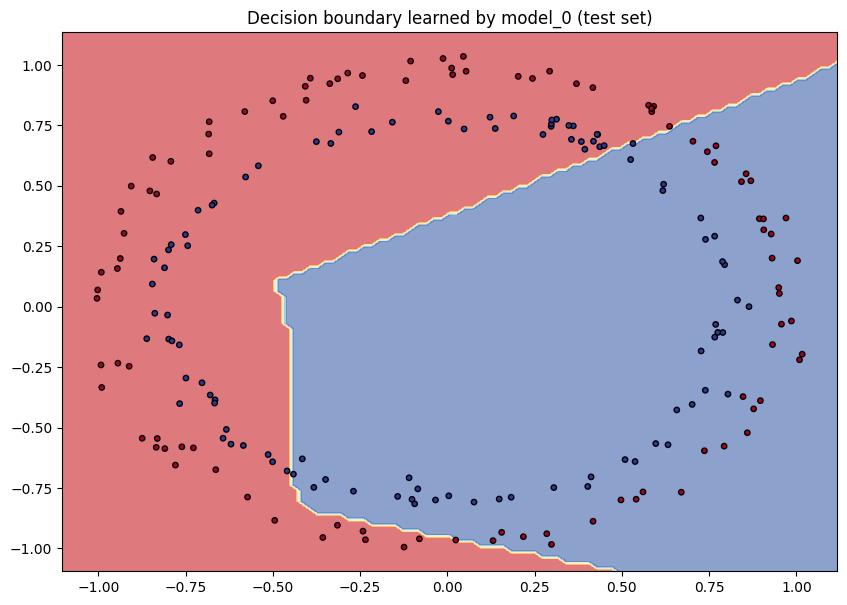

In [ ]:
plt.figure(figsize=(10, 7))
plot_decision_boundary(model_0, X_test, y_test)
plt.title("Decision boundary learned by model_0 (test set)");

---
## 9. 🧪 New experiment — why does the model need non-linearity?

What happens if we stack `Linear` layers with nothing in between? Mathematically, **a stack of linear layers with no activation collapses into a single linear layer**, no matter how deep it is (`W2(W1x + b1) + b2` is still just `Wx + b` for some combined `W, b`). A purely linear model can only draw a **straight line** through 2‑D space — and no straight line can separate two concentric circles.

| Function | What it does |
|---|---|
| `torch.optim.SGD` (reused) | identical optimizer/hyperparameters for both models below, so the comparison isolates the effect of removing `ReLU` |

In [ ]:
# Two IDENTICAL architectures, trained with IDENTICAL settings -- the only difference is ReLU.
model_relu = nn.Sequential(
    nn.Linear(in_features=2, out_features=10),
    nn.ReLU(),
    nn.Linear(in_features=10, out_features=10),
    nn.ReLU(),
    nn.Linear(in_features=10, out_features=1)
).to(device)

model_linear_only = nn.Sequential(
    nn.Linear(in_features=2, out_features=10),
    nn.Linear(in_features=10, out_features=10),
    nn.Linear(in_features=10, out_features=1)
    # No nn.ReLU() anywhere -> this collapses into one big linear layer
).to(device)

loss_fn = nn.BCEWithLogitsLoss()
epochs = 2000  # SGD needs a fair number of epochs here -- see the printout below for how slowly it climbs

def train_binary_model(model, epochs):
    """Same 5-step loop as §7, wrapped as a function so we can call it identically for both models."""
    optimizer = torch.optim.SGD(params=model.parameters(), lr=0.1)
    for epoch in range(epochs):
        model.train()
        y_logits = model(X_train).squeeze()
        y_pred = torch.round(torch.sigmoid(y_logits))
        loss = loss_fn(y_logits, y_train)
        acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.inference_mode():
            test_logits = model(X_test).squeeze()
            test_pred = torch.round(torch.sigmoid(test_logits))
            test_loss = loss_fn(test_logits, y_test)
            test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

        if epoch % 400 == 0:
            print(f"Epoch {epoch:4d} | Train Loss: {loss:.4f}, Acc: {acc:5.2f}% | Test Loss: {test_loss:.4f}, Test Acc: {test_acc:5.2f}%")
    return test_acc

torch.manual_seed(42)
print("--- Training model_relu (WITH non-linearity) ---")
relu_test_acc = train_binary_model(model_relu, epochs)

torch.manual_seed(42)
print("\n--- Training model_linear_only (WITHOUT non-linearity) ---")
linear_test_acc = train_binary_model(model_linear_only, epochs)

--- Training model_relu (WITH non-linearity) ---
Epoch    0 | Train Loss: 0.6929, Acc: 50.00% | Test Loss: 0.6932, Test Acc: 50.00%


Epoch  400 | Train Loss: 0.6852, Acc: 52.75% | Test Loss: 0.6841, Test Acc: 56.50%


Epoch  800 | Train Loss: 0.6516, Acc: 64.00% | Test Loss: 0.6476, Test Acc: 67.50%


Epoch 1200 | Train Loss: 0.3706, Acc: 97.75% | Test Loss: 0.4059, Test Acc: 92.00%


Epoch 1600 | Train Loss: 0.0912, Acc: 99.88% | Test Loss: 0.1274, Test Acc: 99.50%



--- Training model_linear_only (WITHOUT non-linearity) ---
Epoch    0 | Train Loss: 0.6953, Acc: 51.38% | Test Loss: 0.6925, Test Acc: 50.50%


Epoch  400 | Train Loss: 0.6930, Acc: 51.38% | Test Loss: 0.6941, Test Acc: 46.50%


Epoch  800 | Train Loss: 0.6930, Acc: 51.50% | Test Loss: 0.6946, Test Acc: 44.50%


Epoch 1200 | Train Loss: 0.6930, Acc: 51.12% | Test Loss: 0.6947, Test Acc: 45.50%


Epoch 1600 | Train Loss: 0.6930, Acc: 51.00% | Test Loss: 0.6947, Test Acc: 46.00%


Now compare the decision boundaries side-by-side:

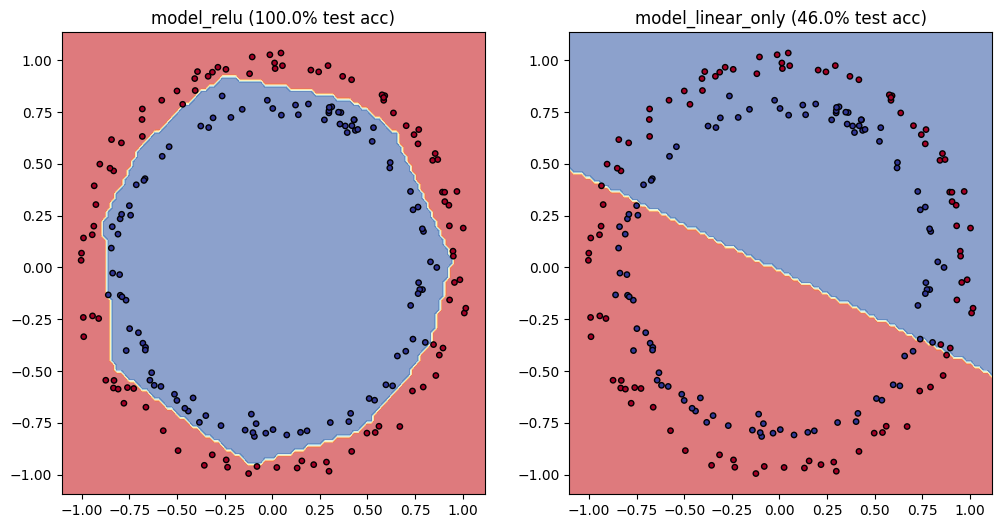

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title(f"model_relu ({relu_test_acc:.1f}% test acc)")
plot_decision_boundary(model_relu, X_test, y_test)
plt.subplot(1, 2, 2)
plt.title(f"model_linear_only ({linear_test_acc:.1f}% test acc)")
plot_decision_boundary(model_linear_only, X_test, y_test)

**Result:** with everything else held identical, `model_relu` carves out a curved region and reaches high accuracy, while `model_linear_only` stays stuck near **50%** — chance level for a balanced 2‑class problem — because the best it can do is slice the plane with one straight line, and no single straight line separates two concentric circles. This isolates non-linearity as the deciding factor: it's *the* reason activation functions like `ReLU` exist — they let a network approximate curved, non-linear decision boundaries. See [PyTorch's `nn` docs on non-linear activations](https://docs.pytorch.org/docs/2.13/nn.html#non-linear-activations-weighted-sum-nonlinearity) for the full list available (`ReLU`, `LeakyReLU`, `GELU`, `Tanh`, `Sigmoid`, ...).

---
## 10. 🧪 New experiment — a deeper network with the Adam optimizer

> **🆕 Added section.** The original notebook only *listed* improvement ideas (§11 below) without trying any of them. Here we actually implement two of the suggested levers together: **more hidden units/layers** and **a different optimizer**.

[`torch.optim.Adam`](https://docs.pytorch.org/docs/2.13/generated/torch.optim.Adam.html) adapts its learning rate per-parameter using estimates of the gradient's first and second moments, and in practice often converges faster than plain SGD, especially early in training.

| Class | Signature | What it does |
|---|---|---|
| `torch.optim.Adam(params, lr)` | — | Adam optimizer — adaptive per-parameter learning rates, usually converges faster than vanilla SGD |

In [ ]:
model_deeper = nn.Sequential(
    nn.Linear(in_features=2, out_features=10),
    nn.ReLU(),
    nn.Linear(in_features=10, out_features=10),
    nn.ReLU(),
    nn.Linear(in_features=10, out_features=1)
).to(device)

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params=model_deeper.parameters(), lr=0.01)  # Adam instead of SGD

torch.manual_seed(42)
epochs = 100

for epoch in range(epochs):
    model_deeper.train()
    y_logits = model_deeper(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_deeper.eval()
    with torch.inference_mode():
        test_logits = model_deeper(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Train Loss: {loss:.4f}, Acc: {acc:5.2f}% | Test Loss: {test_loss:.4f}, Test Acc: {test_acc:5.2f}%")

Epoch   0 | Train Loss: 0.6929, Acc: 50.00% | Test Loss: 0.6920, Test Acc: 55.50%
Epoch  10 | Train Loss: 0.6865, Acc: 53.00% | Test Loss: 0.6840, Test Acc: 56.50%
Epoch  20 | Train Loss: 0.6770, Acc: 53.50% | Test Loss: 0.6715, Test Acc: 57.00%
Epoch  30 | Train Loss: 0.6608, Acc: 60.75% | Test Loss: 0.6530, Test Acc: 62.00%
Epoch  40 | Train Loss: 0.6324, Acc: 66.88% | Test Loss: 0.6234, Test Acc: 70.00%
Epoch  50 | Train Loss: 0.5851, Acc: 74.25% | Test Loss: 0.5770, Test Acc: 76.50%
Epoch  60 | Train Loss: 0.5204, Acc: 81.50% | Test Loss: 0.5294, Test Acc: 81.00%
Epoch  70 | Train Loss: 0.4358, Acc: 90.75% | Test Loss: 0.4549, Test Acc: 89.00%
Epoch  80 | Train Loss: 0.3395, Acc: 96.50% | Test Loss: 0.3586, Test Acc: 95.50%
Epoch  90 | Train Loss: 0.2477, Acc: 98.50% | Test Loss: 0.2724, Test Acc: 97.00%


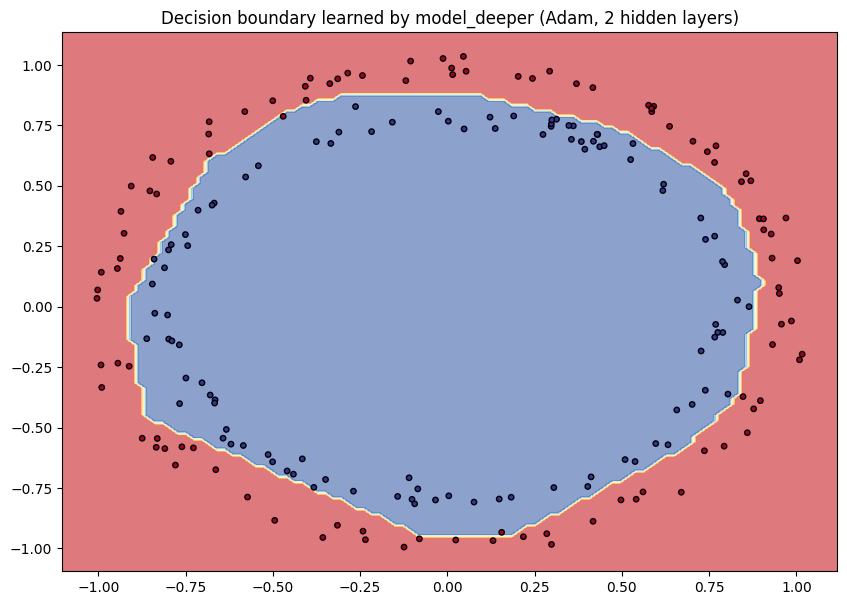

In [ ]:
plt.figure(figsize=(10, 7))
plot_decision_boundary(model_deeper, X_test, y_test)
plt.title("Decision boundary learned by model_deeper (Adam, 2 hidden layers)");

**Takeaway:** on a dataset this simple, `model_0` already reaches ~100% — so `model_deeper` mostly demonstrates that it *converges faster / more smoothly* thanks to Adam, not that it reaches meaningfully higher accuracy. More capacity and adaptive optimizers matter far more on harder, higher-dimensional problems; on easy 2‑D toy data they're a "nice to have," not a necessity. This matches the general guidance in [learnpytorch.io §6](https://www.learnpytorch.io/02_pytorch_classification/#6-improving-a-model-from-a-model-perspective) on the improvement levers available to you.

---
## 11. 🧪 Bonus — comparing other classification algorithms

> **🆕 Added section**, directly answering "what other methods/algorithms could solve this?" Neural networks aren't the only way to do classification. Let's benchmark two classic [scikit-learn](https://scikit-learn.org/stable/supervised_learning.html) algorithms against our neural net on the *exact same* circles data:
> - **[Logistic Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)** — a *linear* classifier. Expect it to struggle for the same reason `model_linear_only` did in §9.
> - **[k-Nearest Neighbors (KNN)](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)** — a non-parametric, inherently non-linear classifier that predicts a point's class by majority vote among its `k` closest training points, so it needs no gradient descent at all.

| Class | Signature | What it does |
|---|---|---|
| `LogisticRegression()` | from `sklearn.linear_model` | fits a linear decision boundary via maximum likelihood |
| `KNeighborsClassifier(n_neighbors)` | from `sklearn.neighbors` | classifies a point by majority vote of its `k` nearest training points |
| `model.score(X, y)` | sklearn convention | returns mean accuracy on the given data |

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# sklearn works with plain numpy arrays on the CPU
X_train_np, X_test_np = X_train.cpu().numpy(), X_test.cpu().numpy()
y_train_np, y_test_np = y_train.cpu().numpy(), y_test.cpu().numpy()

log_reg = LogisticRegression().fit(X_train_np, y_train_np)
knn = KNeighborsClassifier(n_neighbors=5).fit(X_train_np, y_train_np)


# Using model_deeper from §10 rather than model_0 -- model_0 was intentionally left undertrained
# in §7 to make a point; model_deeper is the one that actually converged well, so it's the fair
# neural-net representative to benchmark against these two fully-converged sklearn models.
nn_test_acc = accuracy_fn(y_true=y_test, y_pred=torch.round(torch.sigmoid(model_deeper(X_test).squeeze())))

print(f"Logistic Regression test accuracy:      {log_reg.score(X_test_np, y_test_np) * 100:.2f}%")
print(f"KNN (k=5) test accuracy:                {knn.score(X_test_np, y_test_np) * 100:.2f}%")
print(f"Neural net (model_deeper) test accuracy: {nn_test_acc:.2f}%")

Logistic Regression test accuracy:      45.00%
KNN (k=5) test accuracy:                100.00%
Neural net (model_deeper) test accuracy: 99.00%


Reuse the same meshgrid technique from §8, adapted for scikit-learn's `.predict()` API, to visualize all three side-by-side:

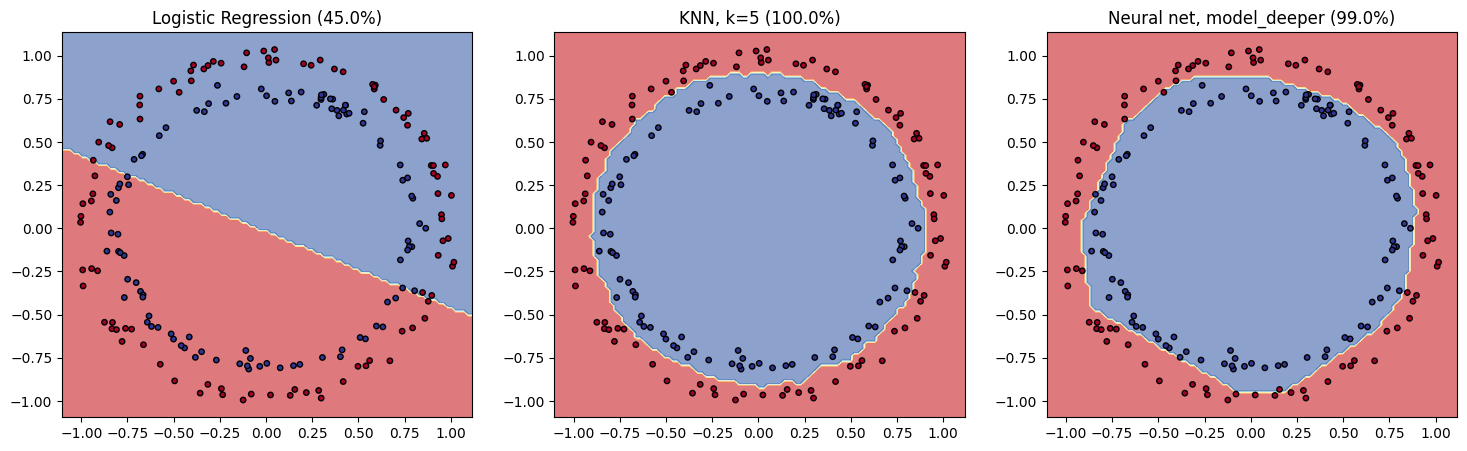

In [ ]:
def plot_sklearn_decision_boundary(model, X, y):
    """Same idea as plot_decision_boundary(), but for a fitted scikit-learn model."""
    X, y = X.cpu().numpy(), y.cpu().numpy()
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101),
                          np.linspace(y_min, y_max, 101))

    grid_labels = model.predict(np.column_stack((xx.ravel(), yy.ravel()))).reshape(xx.shape)

    plt.contourf(xx, yy, grid_labels, cmap=plt.cm.RdYlBu, alpha=0.6)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolors="k", s=15)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.title(f"Logistic Regression ({log_reg.score(X_test_np, y_test_np) * 100:.1f}%)")
plot_sklearn_decision_boundary(log_reg, X_test, y_test)
plt.subplot(1, 3, 2)
plt.title(f"KNN, k=5 ({knn.score(X_test_np, y_test_np) * 100:.1f}%)")
plot_sklearn_decision_boundary(knn, X_test, y_test)
plt.subplot(1, 3, 3)
plt.title(f"Neural net, model_deeper ({nn_test_acc:.1f}%)")
plot_decision_boundary(model_deeper, X_test, y_test)

**Takeaway:** Logistic Regression is stuck at chance level for the same reason `model_linear_only` was — it's a linear model facing a non-linearly-separable problem. KNN and the neural net both solve it, but in very different ways: KNN memorizes the training data and does a local vote at prediction time (no training/backprop at all, but it must store the whole training set and gets slower as data grows); the neural net *learns* a compact set of weights that generalize to a smooth curved boundary. For toy 2‑D data like this, all three "non-linear-capable" approaches are valid — the neural net's real advantage shows up on much higher-dimensional, larger-scale problems (images, text, etc.) where KNN becomes impractical and hand-crafted linear features run out of expressiveness.

---
## 12. More ideas for improving the model

Beyond what we tried above, other levers to reach for, roughly in order of how cheap they are to test:
- **Fit for longer** — more epochs
- **Change the activation function** — e.g. swap `ReLU` for `LeakyReLU` or `ELU`
- **Change the learning rate** — too high overshoots, too low trains slowly
- **Change the loss function** — appropriate for the problem type
- **Tune the optimizer's own hyperparameters** — e.g. `betas`, `weight_decay` for Adam
- **Regularization** — `weight_decay` in the optimizer, or `nn.Dropout` layers, if the model starts overfitting on harder data

---
## 13. Saving and loading the model

| Function | What it does |
|---|---|
| `torch.save(obj, f)` | serializes an object (here, a `state_dict`) to disk |
| `torch.load(f)` | deserializes it back (defaults to `weights_only=True` since PyTorch 2.6 — fine here, since we only ever save a plain `state_dict` of tensors) |
| `model.load_state_dict(state_dict)` | loads saved parameter values into a model instance |

In [ ]:
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "02_pytorch_classification_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state_dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(), f=MODEL_SAVE_PATH)

Saving model to: models/02_pytorch_classification_model_0.pth


In [ ]:
# Instantiate a fresh instance of the same architecture
loaded_model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.ReLU(),
    nn.Linear(in_features=5, out_features=1)
).to(device)

# Load the saved state_dict
loaded_model_0.load_state_dict(torch.load(MODEL_SAVE_PATH))

print(f"Loaded model:\n{loaded_model_0}")
print(f"Model on device: {next(loaded_model_0.parameters()).device}")

# Evaluate the loaded model and compare against the original model's predictions
loaded_model_0.eval()
model_0.eval()
with torch.inference_mode():
    loaded_preds = torch.round(torch.sigmoid(loaded_model_0(X_test).squeeze()))
    original_preds = torch.round(torch.sigmoid(model_0(X_test).squeeze()))

# Should be all True
loaded_preds == original_preds

Loaded model:
Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): ReLU()
  (2): Linear(in_features=5, out_features=1, bias=True)
)
Model on device: cpu


tensor([True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, Tr

---
# 📋 Cheat Sheet (Part 1) — binary classification & experiments

### Data
| Function | Signature | What it does |
|---|---|---|
| `make_circles` | `make_circles(n_samples, noise, random_state)` | generates a toy 2-class, 2-D "two circles" dataset |
| `pd.DataFrame` | `pd.DataFrame({col: values, ...})` | builds a table from equal-length columns |
| `train_test_split` | `train_test_split(X, y, test_size, random_state)` | splits data into train/test subsets |
| `torch.from_numpy` | `torch.from_numpy(ndarray)` | wraps a NumPy array as a tensor |
| `Tensor.type` | `tensor.type(dtype)` | casts a tensor to a different dtype |

### Building models
| Function | Signature | What it does |
|---|---|---|
| `nn.Module` | base class | parent class for all models/layers |
| `nn.Linear` | `nn.Linear(in_features, out_features)` | fully-connected layer: `y = xW^T + b` |
| `nn.ReLU` | `nn.ReLU()` | `max(0, x)` non-linear activation |
| `nn.Sequential` | `nn.Sequential(layer1, layer2, ...)` | chains layers together without writing a custom `forward()` |
| `model.to(device)` | — | moves a model's parameters to a device |

### Training
| Function | Signature | What it does |
|---|---|---|
| `nn.BCEWithLogitsLoss` | `nn.BCEWithLogitsLoss()` | sigmoid + binary cross-entropy in one numerically-stable step; expects raw logits |
| `torch.sigmoid` | `torch.sigmoid(x)` | squashes values into `[0, 1]` |
| `torch.round` | `torch.round(x)` | rounds to the nearest integer (here: `0.` or `1.`) |
| `Tensor.squeeze` | `tensor.squeeze()` | removes size-1 dimensions — critical for matching shapes before a loss/accuracy calculation |
| `torch.eq` | `torch.eq(a, b)` | element-wise equality, returns a boolean tensor |
| `torch.optim.SGD` | `SGD(params, lr)` | Stochastic Gradient Descent optimizer |
| `torch.optim.Adam` | `Adam(params, lr)` | adaptive-learning-rate optimizer, often converges faster than SGD |
| `optimizer.zero_grad()` / `loss.backward()` / `optimizer.step()` | — | the standard 3-step gradient update |
| `model.train()` / `model.eval()` | — | switch between training and evaluation mode |
| `torch.inference_mode()` | context manager | disables gradient tracking for faster inference |
| `torch.manual_seed` / `torch.cuda.manual_seed` | `manual_seed(seed)` | seed CPU / GPU RNGs for reproducibility |

### Visualization
| Function | What it does |
|---|---|
| `plt.scatter(x, y, c, cmap)` | scatter plot, colored by the `c` array using colormap `cmap` |
| `np.meshgrid(x, y)` | builds 2-D coordinate grids from 1-D arrays |
| `plt.contourf(xx, yy, Z)` | filled contour plot — used here to shade decision regions |

### Classic ML baselines (§11)
| Function | Signature | What it does |
|---|---|---|
| `LogisticRegression` | from `sklearn.linear_model` | linear classifier |
| `KNeighborsClassifier` | from `sklearn.neighbors` | non-parametric, non-linear classifier |
| `model.score(X, y)` | — | sklearn's built-in accuracy scorer |

### Saving & loading
| Function | What it does |
|---|---|
| `torch.save(obj, f)` | serializes an object to disk |
| `torch.load(f)` | deserializes a saved object |
| `model.load_state_dict(state_dict)` | loads saved parameters into a model |
| `pathlib.Path`, `Path.mkdir()` | OS-independent paths; creates directories |

---
# 🎯 Part 2 — Multi-class classification

Everything above was **binary** classification (2 classes: `0` or `1`). Now we extend the same workflow to **multi-class** classification (more than 2 classes) using scikit-learn's `make_blobs` to generate 4 separate clusters. The core steps are identical — get data, build model, pick loss/optimizer, train, evaluate — but a few pieces change:

| | Binary | Multi-class |
|---|---|---|
| Output layer size | 1 (a single logit) | `num_classes` (one logit per class) |
| Loss function | `nn.BCEWithLogitsLoss` | `nn.CrossEntropyLoss` |
| Logits → probabilities | `torch.sigmoid` | `torch.softmax(dim=1)` |
| Probabilities → labels | `torch.round` | `torch.argmax(dim=1)` |



## 14. Get multi-class data

| Function | Signature | What it does |
|---|---|---|
| `make_blobs(n_samples, n_features, centers, cluster_std, random_state)` | from `sklearn.datasets` | generates isotropic Gaussian blobs — `centers` sets the number of classes |
| `Tensor.type(torch.LongTensor)` | — | multi-class labels must be `int64` (`Long`) for `nn.CrossEntropyLoss`, unlike the `float` labels binary classification used |

tensor([[-8.4134,  6.9352],
        [-5.7665, -6.4312],
        [-6.0421, -6.7661],
        [ 3.9508,  0.6984],
        [ 4.2505, -0.2815]]) tensor([3, 2, 2, 1, 1])


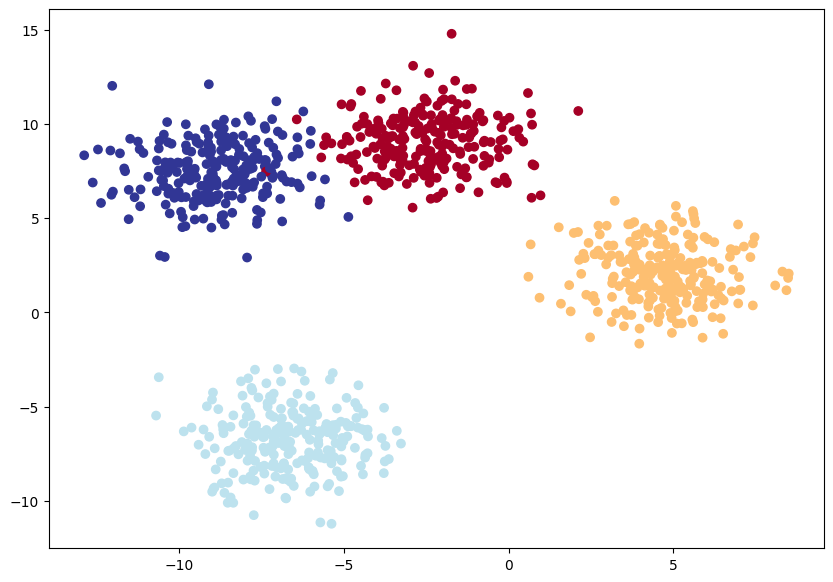

In [ ]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Set the hyperparameters for data creation
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

# 1. Create multi-class data
X_blob, y_blob = make_blobs(n_samples=1000,
    n_features=NUM_FEATURES, # X features
    centers=NUM_CLASSES, # y labels
    cluster_std=1.5, # give the clusters a little shake up (try changing this to 1.0, the default)
    random_state=RANDOM_SEED
)

# 2. Turn data into tensors
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)
print(X_blob[:5], y_blob[:5])

# 3. Split into train and test sets
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
    y_blob,
    test_size=0.2,
    random_state=RANDOM_SEED
)

# 4. Plot data
plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu);

## 15. Device-agnostic code

Same pattern as §3 — re-run in case this section is executed independently.

In [ ]:
# Create device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

## 16. Build the model

A deeper, wider network than `model_0`: `2 → 8 → 8 → 4`, with `hidden_units` and `output_features` as constructor arguments so the same class can be reused for other datasets. The `ReLU`s are commented out on purpose — `make_blobs` clusters are already linearly separable (unlike the circles), so try training with and without them uncommented to see for yourself that they barely matter here, in contrast to §9 where removing `ReLU` was catastrophic.

| Class | What it does |
|---|---|
| `nn.Sequential` (reused) | stacks the 3 `Linear` layers |
| docstring `Args:` block | documents constructor parameters — good practice for any reusable model class |

In [ ]:
#building the model
from torch import nn

# Build model
class BlobModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units=8):
        """Initializes all required hyperparameters for a multi-class classification model.

        Args:
            input_features (int): Number of input features to the model.
            out_features (int): Number of output features of the model
              (how many classes there are).
            hidden_units (int): Number of hidden units between layers, default 8.
        """
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            # nn.ReLU(), # <- does our dataset require non-linear layers? (try uncommenting and see if the results change)
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            # nn.ReLU(), # <- does our dataset require non-linear layers? (try uncommenting and see if the results change)
            nn.Linear(in_features=hidden_units, out_features=output_features), # how many classes are there?
        )

    def forward(self, x):
        return self.linear_layer_stack(x)

# Create an instance of BlobModel and send it to the target device
model_4 = BlobModel(input_features=NUM_FEATURES,
                    output_features=NUM_CLASSES,
                    hidden_units=8).to(device)
model_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

## 17. Loss function & optimizer

`nn.CrossEntropyLoss` is the multi-class equivalent of `nn.BCEWithLogitsLoss` — it combines `LogSoftmax` and negative log-likelihood loss into one numerically-stable step, and (like `BCEWithLogitsLoss`) expects **raw logits**, not pre-softmaxed probabilities.

| Class | Signature | What it does |
|---|---|---|
| `nn.CrossEntropyLoss()` | — | softmax + negative log-likelihood in one step; expects raw logits + integer class-index targets |

In [ ]:
# Create loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_4.parameters(),
                            lr=0.1)

## 18. Sanity-check a forward pass

Always worth confirming shapes line up before writing a training loop.

In [ ]:
# Perform a single forward pass on the data (we'll need to put it to the target device for it to work)
model_4(X_blob_train.to(device))[:5]

tensor([[ 0.2677,  0.5023,  0.1956,  0.1440],
        [ 1.4990,  0.0459,  0.1301,  0.6409],
        [-1.0662, -0.7139, -0.9366, -0.0573],
        [-0.4702, -0.4492, -0.6267,  0.0875],
        [ 1.1793, -0.0472, -0.0017,  0.5536]], grad_fn=<SliceBackward0>)

In [ ]:
# How many elements in a single prediction sample?
model_4(X_blob_train.to(device))[0].shape, NUM_CLASSES

(torch.Size([4]), 4)

## 19. From logits → probabilities → labels (multi-class version)

The multi-class analogue of §6: instead of `sigmoid` (which only makes sense for a single logit), we use [`torch.softmax`](https://docs.pytorch.org/docs/2.13/generated/torch.nn.functional.softmax.html) across the class dimension (`dim=1`) to turn `NUM_CLASSES` raw logits into a probability distribution that sums to 1.

| Function | What it does |
|---|---|
| `torch.softmax(x, dim)` | exponentiates and normalizes logits along `dim` so they sum to 1 — a probability distribution over classes |
| `torch.argmax(x, dim)` | returns the index of the largest value along `dim` — the predicted class |

In [ ]:
#usage of softmax function

# Make prediction logits with model
y_logits = model_4(X_blob_test.to(device))

# Perform softmax calculation on logits across dimension 1 to get prediction probabilities
y_pred_probs = torch.softmax(y_logits, dim=1)
print(y_logits[:5])
print(y_pred_probs[:5])

tensor([[ 4.5961e-01,  4.9549e-01,  2.3061e-01,  2.0876e-01],
        [ 1.3083e+00, -3.9647e-01, -2.2058e-01,  6.6511e-01],
        [-9.7481e-01, -5.2771e-01, -7.8670e-01, -6.3791e-02],
        [-4.8172e-04,  3.6499e-01,  4.3351e-02,  8.2379e-02],
        [ 1.4993e+00,  2.4030e-01,  2.6690e-01,  6.0273e-01]],
       grad_fn=<SliceBackward0>)
tensor([[0.2770, 0.2871, 0.2203, 0.2156],
        [0.5197, 0.0945, 0.1127, 0.2732],
        [0.1598, 0.2499, 0.1929, 0.3974],
        [0.2187, 0.3152, 0.2285, 0.2376],
        [0.5041, 0.1432, 0.1470, 0.2057]], grad_fn=<SliceBackward0>)


In [ ]:
# Sum the first sample output of the softmax activation function
torch.sum(y_pred_probs[0])

tensor(1., grad_fn=<SumBackward0>)

In [ ]:
# Which class does the model think is *most* likely at the index 0 sample?
print(y_pred_probs[0])
print(torch.argmax(y_pred_probs[0]))

tensor([0.2770, 0.2871, 0.2203, 0.2156], grad_fn=<SelectBackward0>)
tensor(1)


## 20. Training and testing loop

Same 5-step loop as §7, with the substitutions from the table at the top of this section: `CrossEntropyLoss` instead of `BCEWithLogitsLoss`, and `softmax` + `argmax` instead of `sigmoid` + `round`.

In [ ]:
#creating the traing loop

# Fit the model
torch.manual_seed(42)

# Set number of epochs
epochs = 100

# Put data to target device
X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

for epoch in range(epochs):
    ### Training
    model_4.train()

    # 1. Forward pass
    y_logits = model_4(X_blob_train) # model outputs raw logits
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) # go from logits -> prediction probabilities -> prediction labels
    # print(y_logits)
    # 2. Calculate loss and accuracy
    loss = loss_fn(y_logits, y_blob_train)
    acc = accuracy_fn(y_true=y_blob_train,
                      y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_4.eval()
    with torch.inference_mode():
      # 1. Forward pass
      test_logits = model_4(X_blob_test)
      test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
      # 2. Calculate test loss and accuracy
      test_loss = loss_fn(test_logits, y_blob_test)
      test_acc = accuracy_fn(y_true=y_blob_test,
                             y_pred=test_pred)

    # Print out what's happening
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 1.20091, Acc: 48.50% | Test Loss: 1.20181, Test Acc: 64.50%
Epoch: 10 | Loss: 0.20870, Acc: 97.38% | Test Loss: 0.18490, Test Acc: 97.50%
Epoch: 20 | Loss: 0.09655, Acc: 99.00% | Test Loss: 0.08542, Test Acc: 99.50%
Epoch: 30 | Loss: 0.06654, Acc: 99.12% | Test Loss: 0.05883, Test Acc: 99.50%
Epoch: 40 | Loss: 0.05333, Acc: 99.12% | Test Loss: 0.04564, Test Acc: 99.50%
Epoch: 50 | Loss: 0.04597, Acc: 99.12% | Test Loss: 0.03811, Test Acc: 99.50%
Epoch: 60 | Loss: 0.04135, Acc: 99.12% | Test Loss: 0.03329, Test Acc: 99.50%
Epoch: 70 | Loss: 0.03821, Acc: 99.12% | Test Loss: 0.02995, Test Acc: 99.50%
Epoch: 80 | Loss: 0.03595, Acc: 99.12% | Test Loss: 0.02751, Test Acc: 99.50%
Epoch: 90 | Loss: 0.03426, Acc: 99.12% | Test Loss: 0.02565, Test Acc: 99.50%


## 21. Inspect predictions vs. true labels



In [ ]:
# Make sure we're evaluating on the TEST set, not reusing a stale training-loop variable
model_4.eval()
with torch.inference_mode():
    y_logits = model_4(X_blob_test)

# Turn predicted logits in prediction probabilities
y_pred_probs = torch.softmax(y_logits, dim=1)

# Turn prediction probabilities into prediction labels
y_preds = y_pred_probs.argmax(dim=1)

# Compare first 10 model preds and test labels
print(f"Predictions: {y_preds[:10]}\nLabels: {y_blob_test[:10]}")
print(f"Test accuracy: {accuracy_fn(y_true=y_blob_test, y_pred=y_preds)}%")

Predictions: tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])
Labels: tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])
Test accuracy: 99.5%


## 22. Visualize the decision boundaries

Thanks to the fix in §8, the same `plot_decision_boundary` function works unchanged here — it detects that `model_4` outputs 4 logits per sample and automatically uses `softmax` + `argmax` instead of `sigmoid` + `round`.

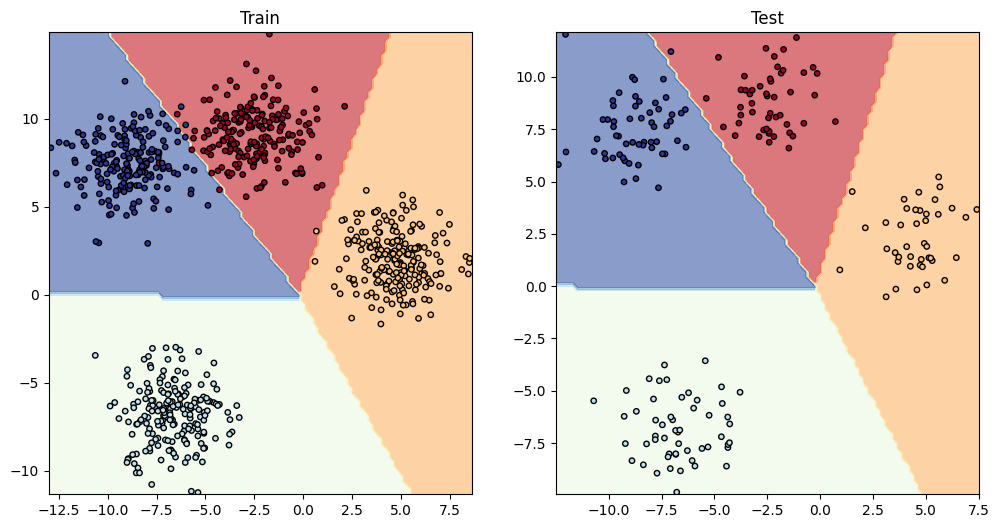

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_4, X_blob_test, y_blob_test)

## 23. Accuracy with TorchMetrics

[`torchmetrics`](https://lightning.ai/docs/torchmetrics/stable/) provides pre-built, tested metric implementations so you don't have to hand-roll every metric yourself.

| Class | Signature | What it does |
|---|---|---|
| `torchmetrics.Accuracy(task, num_classes)` | — | computes classification accuracy; `task` selects `"binary"` / `"multiclass"` / `"multilabel"` behavior |

In [ ]:
try:
    from torchmetrics import Accuracy
except ImportError:
    !pip install -q torchmetrics  # unpinned: task= requires torchmetrics >= 0.11
    from torchmetrics import Accuracy

# Setup metric and make sure it's on the target device
torchmetrics_accuracy = Accuracy(task="multiclass", num_classes=NUM_CLASSES).to(device)

# Calculate accuracy
torchmetrics_accuracy(y_preds, y_blob_test)

tensor(0.9950)

---
## 24. 🧪 More classification evaluation metrics — now implemented



| Metric | Definition | Code |
|---|---|---|
| Accuracy | Out of 100 predictions, how many does your model get correct? | `torchmetrics.Accuracy()` or `sklearn.metrics.accuracy_score()` |
| Precision | Proportion of true positives over all predicted positives. Higher precision = fewer false positives. | `torchmetrics.Precision()` or `sklearn.metrics.precision_score()` |
| Recall | Proportion of true positives over all actual positives. Higher recall = fewer false negatives. | `torchmetrics.Recall()` or `sklearn.metrics.recall_score()` |
| F1-score | Harmonic mean of precision and recall — 1 is best, 0 is worst. | `torchmetrics.F1Score()` or `sklearn.metrics.f1_score()` |
| Confusion matrix | Table of predicted vs. true labels — a perfect model has all counts on the diagonal. | `torchmetrics.ConfusionMatrix` or `sklearn.metrics.confusion_matrix()` |
| Classification report | One-shot summary combining precision, recall, and F1 per class. | `sklearn.metrics.classification_report()` |

For a 4-class problem, precision/recall/F1 need an **averaging strategy** across classes — `average="macro"` below treats every class equally regardless of how many samples it has (a good default when classes are roughly balanced, as they are here).

In [ ]:
from torchmetrics import Precision, Recall, F1Score

# --- TorchMetrics (macro-averaged across all classes) ---
precision_fn = Precision(task="multiclass", num_classes=NUM_CLASSES, average="macro").to(device)
recall_fn = Recall(task="multiclass", num_classes=NUM_CLASSES, average="macro").to(device)
f1_fn = F1Score(task="multiclass", num_classes=NUM_CLASSES, average="macro").to(device)

print(f"Accuracy:  {torchmetrics_accuracy(y_preds, y_blob_test):.4f}")
print(f"Precision: {precision_fn(y_preds, y_blob_test):.4f}")
print(f"Recall:    {recall_fn(y_preds, y_blob_test):.4f}")
print(f"F1-score:  {f1_fn(y_preds, y_blob_test):.4f}")

Accuracy:  0.9950
Precision: 0.9950
Recall:    0.9956
F1-score:  0.9953


scikit-learn's `classification_report` gives the same metrics broken down **per class** in one call, which is often more actionable than a single averaged number:

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_blob_test.cpu().numpy(),
    y_preds.cpu().numpy(),
    target_names=[f"class_{i}" for i in range(NUM_CLASSES)]
))

              precision    recall  f1-score   support

     class_0       0.98      1.00      0.99        49
     class_1       1.00      1.00      1.00        41
     class_2       1.00      1.00      1.00        53
     class_3       1.00      0.98      0.99        57

    accuracy                           0.99       200
   macro avg       0.99      1.00      1.00       200
weighted avg       1.00      0.99      1.00       200



Finally, the confusion matrix — visualized with `ConfusionMatrixDisplay` (no extra dependency beyond `scikit-learn`, which this notebook already uses):

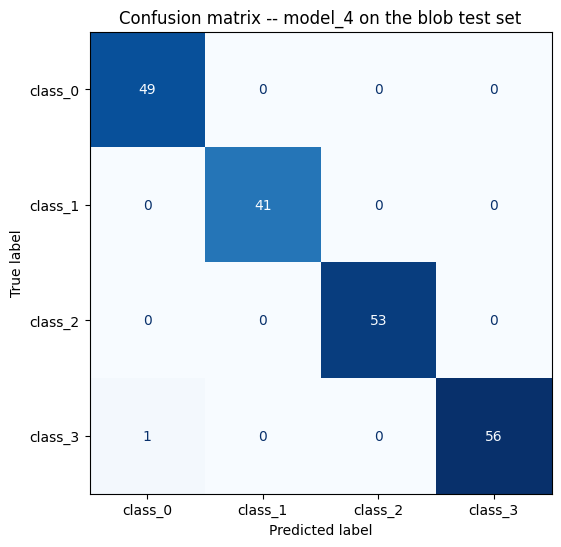

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_blob_test.cpu().numpy(), y_preds.cpu().numpy())
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f"class_{i}" for i in range(NUM_CLASSES)])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
plt.title("Confusion matrix -- model_4 on the blob test set");

A perfect model would show every count sitting on the diagonal (top-left to bottom-right); any off-diagonal counts are misclassifications between those two specific classes.

---
# 📋 Cheat Sheet (Part 2) — multi-class classification & evaluation

### Data
| Function | Signature | What it does |
|---|---|---|
| `make_blobs` | `make_blobs(n_samples, n_features, centers, cluster_std, random_state)` | generates `centers` isotropic Gaussian clusters |
| `Tensor.type(torch.LongTensor)` | — | casts labels to `int64`, required by `nn.CrossEntropyLoss` |

### Building & training
| Function | Signature | What it does |
|---|---|---|
| `nn.CrossEntropyLoss()` | — | softmax + negative log-likelihood in one step; expects raw logits |
| `torch.softmax(x, dim)` | — | converts logits to a probability distribution along `dim` |
| `torch.argmax(x, dim)` | — | index of the largest value along `dim` — the predicted class |

### Evaluation metrics (§24)
| Function | Signature | What it does |
|---|---|---|
| `torchmetrics.Accuracy` | `Accuracy(task, num_classes)` | classification accuracy |
| `torchmetrics.Precision` | `Precision(task, num_classes, average)` | true positives / predicted positives |
| `torchmetrics.Recall` | `Recall(task, num_classes, average)` | true positives / actual positives |
| `torchmetrics.F1Score` | `F1Score(task, num_classes, average)` | harmonic mean of precision & recall |
| `sklearn.metrics.classification_report` | `classification_report(y_true, y_pred)` | per-class precision/recall/F1/support in one table |
| `sklearn.metrics.confusion_matrix` | `confusion_matrix(y_true, y_pred)` | raw predicted-vs-true count matrix |
| `sklearn.metrics.ConfusionMatrixDisplay` | `ConfusionMatrixDisplay(confusion_matrix=cm)` | plots a confusion matrix |

---
### 📚 References
- [01. PyTorch Workflow Fundamentals — learnpytorch.io](https://www.learnpytorch.io/01_pytorch_workflow/)
- [02. PyTorch Neural Network Classification — learnpytorch.io](https://www.learnpytorch.io/02_pytorch_classification/)
- [PyTorch documentation (v2.13)](https://docs.pytorch.org/docs/2.13/index.html)
- [PyTorch `torch.optim` docs](https://docs.pytorch.org/docs/2.13/optim.html)
- [PyTorch non-linear activations](https://docs.pytorch.org/docs/2.13/nn.html#non-linear-activations-weighted-sum-nonlinearity)
- [scikit-learn: Supervised learning](https://scikit-learn.org/stable/supervised_learning.html)
- [scikit-learn: `sklearn.metrics`](https://scikit-learn.org/stable/api/sklearn.metrics.html)
- [TorchMetrics documentation](https://lightning.ai/docs/torchmetrics/stable/)